# Introducción

## Contexto del problema

El cáncer de mama es una de las enfermedades con mayor impacto en la salud pública a nivel mundial. Una detección temprana y precisa puede contribuir significativamente a mejorar el tratamiento y aumentar las probabilidades de supervivencia de los pacientes.

En los últimos años, las técnicas de Machine Learning han demostrado ser herramientas útiles para apoyar procesos de diagnóstico médico, permitiendo identificar patrones complejos en datos clínicos y biomédicos. En particular, los modelos de clasificación supervisada pueden utilizarse para predecir si un tumor es benigno o maligno a partir de características obtenidas de imágenes médicas.

---

## Problema a resolver

En este proyecto se utilizará el Breast Cancer Wisconsin Dataset, el cual contiene información numérica relacionada con características de tumores de mama, tales como radio, textura, perímetro, área y concavidad.

El objetivo principal es construir modelos de Machine Learning capaces de clasificar tumores como benignos o malignos utilizando dichas características. Este problema corresponde a una tarea de clasificación binaria supervisada.

---

## Resumen de la metodología

Para resolver este problema se implementará un flujo completo de Machine Learning utilizando herramientas de Python y scikit-learn.

El proyecto incluirá:

- Análisis exploratorio de datos (EDA)
- Preprocesamiento y normalización
- Selección de características
- Construcción de pipelines
- Optimización de hiperparámetros mediante validación cruzada repetida
- Comparación estadística entre modelos de Machine Learning
- Visualización del espacio de características mediante t-SNE
- Evaluación de métricas de desempeño

Los modelos principales a comparar serán Regresión Logística Regularizada y Support Vector Machines (SVM).

# Exploratory Data Analysis (EDA)

In [1]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS BÁSICAS
# ============================================================

# Librería para manejo de arreglos numéricos
import numpy as np

# Librería para manejo de tablas tipo DataFrame
import pandas as pd

# Librería para gráficos básicos
import matplotlib.pyplot as plt

# Librería para gráficos estadísticos más elaborados
import seaborn as sns

# Dataset Breast Cancer Wisconsin incluido en scikit-learn
from sklearn.datasets import load_breast_cancer


# ============================================================
# 2. CARGAR EL DATASET
# ============================================================

# Cargamos el dataset desde scikit-learn
data = load_breast_cancer()

# Convertimos las variables predictoras en un DataFrame
# data.data contiene los valores numéricos de las características
# data.feature_names contiene los nombres de las columnas
df = pd.DataFrame(data.data, columns=data.feature_names)

# Agregamos la variable objetivo al DataFrame
# data.target contiene la clase de cada observación:
# 0 = maligno
# 1 = benigno
df["target"] = data.target


# ============================================================
# 3. REVISIÓN INICIAL DEL DATASET
# ============================================================

# Mostramos las primeras filas para observar la estructura de la data
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# Dimensiones del dataset
print("Shape del dataset:", df.shape)

# Información general
df.info()

Shape del dataset: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 1

In [3]:
# Valores nulos
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [4]:
# ============================================================
# 4. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

# describe() genera un resumen estadístico de las variables numéricas
# Algunas métricas importantes:
#
# count -> número de observaciones
# mean  -> promedio
# std   -> desviación estándar
# min   -> valor mínimo
# 25%   -> percentil 25
# 50%   -> mediana
# 75%   -> percentil 75
# max   -> valor máximo

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Interpretación de estadísticas descriptivas

A partir de las estadísticas descriptivas se observa que las variables presentan escalas diferentes. Por ejemplo, variables como `mean area` tienen valores mucho mayores que variables como `mean smoothness` o `mean fractal dimension`.

Esto indica que el dataset no se encuentra normalizado, por lo que posteriormente será necesario aplicar una técnica de escalamiento como `StandardScaler`, especialmente porque modelos como Regresión Logística y SVM son sensibles a la escala de los datos.

Además, algunas variables presentan diferencias considerables entre los percentiles y los valores máximos, lo cual podría indicar la presencia de valores atípicos (outliers).

target
1    357
0    212
Name: count, dtype: int64


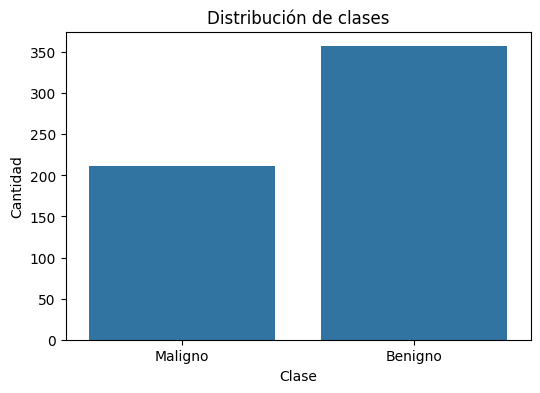

In [5]:
# ============================================================
# 5. DISTRIBUCIÓN DE CLASES
# ============================================================

# Contamos cuántas observaciones existen por clase
# 0 = maligno
# 1 = benigno
class_counts = df["target"].value_counts()

# Mostrar cantidades por clase
print(class_counts)

# Crear figura
plt.figure(figsize=(6,4))

# countplot permite visualizar cuántas observaciones
# existen en cada categoría
sns.countplot(x=df["target"])

# Título del gráfico
plt.title("Distribución de clases")

# Etiquetas de ejes
plt.xlabel("Clase")
plt.ylabel("Cantidad")

# Cambiamos los nombres numéricos por etiquetas más entendibles
plt.xticks(
    ticks=[0,1],
    labels=["Maligno", "Benigno"]
)

# Mostrar gráfico
plt.show()

## Interpretación de la distribución de clases

Se observa que el dataset presenta una mayor cantidad de tumores benignos (357 casos) en comparación con tumores malignos (212 casos).

Aunque existe un ligero desbalance entre clases, este no es extremo, por lo que inicialmente no parece necesario aplicar técnicas de balanceo como oversampling o undersampling.

Mantener una distribución relativamente equilibrada es importante para evitar que los modelos se sesguen hacia la clase mayoritaria.

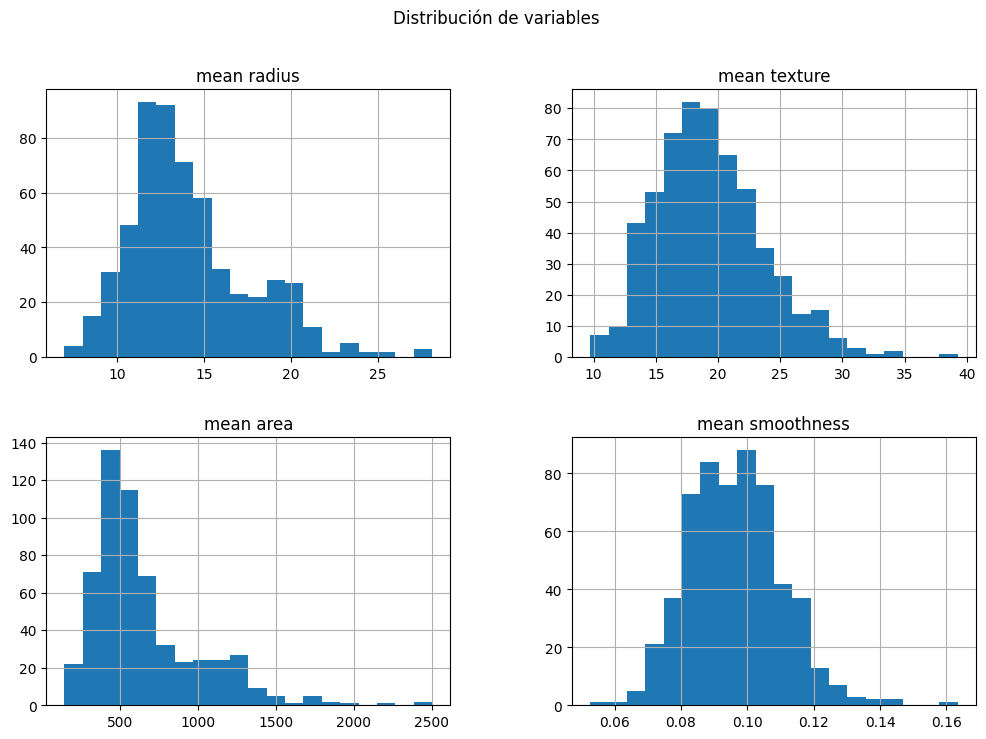

In [6]:
# ============================================================
# 6. DISTRIBUCIÓN DE VARIABLES
# ============================================================

# Seleccionamos algunas variables representativas del dataset
# Estas variables describen diferentes propiedades del tumor:
#
# mean radius      -> tamaño promedio
# mean texture     -> textura promedio
# mean area        -> área promedio
# mean smoothness  -> suavidad del borde
#
# Se escogieron porque presentan diferentes escalas
# y permiten visualizar mejor la distribución de los datos.

features = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean smoothness"
]

# Generar histogramas para observar la distribución
# de cada variable
df[features].hist(
    figsize=(12,8),
    bins=20
)

# Título general
plt.suptitle("Distribución de variables")

# Mostrar gráficos
plt.show()

## Interpretación de la distribución de variables

Se observa que las variables presentan distribuciones diferentes y escalas considerablemente distintas.

Por ejemplo, `mean area` posee valores mucho mayores que `mean smoothness`, lo cual confirma que la data no se encuentra normalizada. Esto es importante porque modelos como Regresión Logística y SVM son sensibles a la escala de las variables.

Además, algunas distribuciones presentan ligeras asimetrías y posibles valores extremos, especialmente en variables como `mean radius` y `mean area`, donde existen observaciones alejadas de la mayor concentración de datos.

Por esta razón, posteriormente se aplicará un proceso de estandarización utilizando `StandardScaler`.

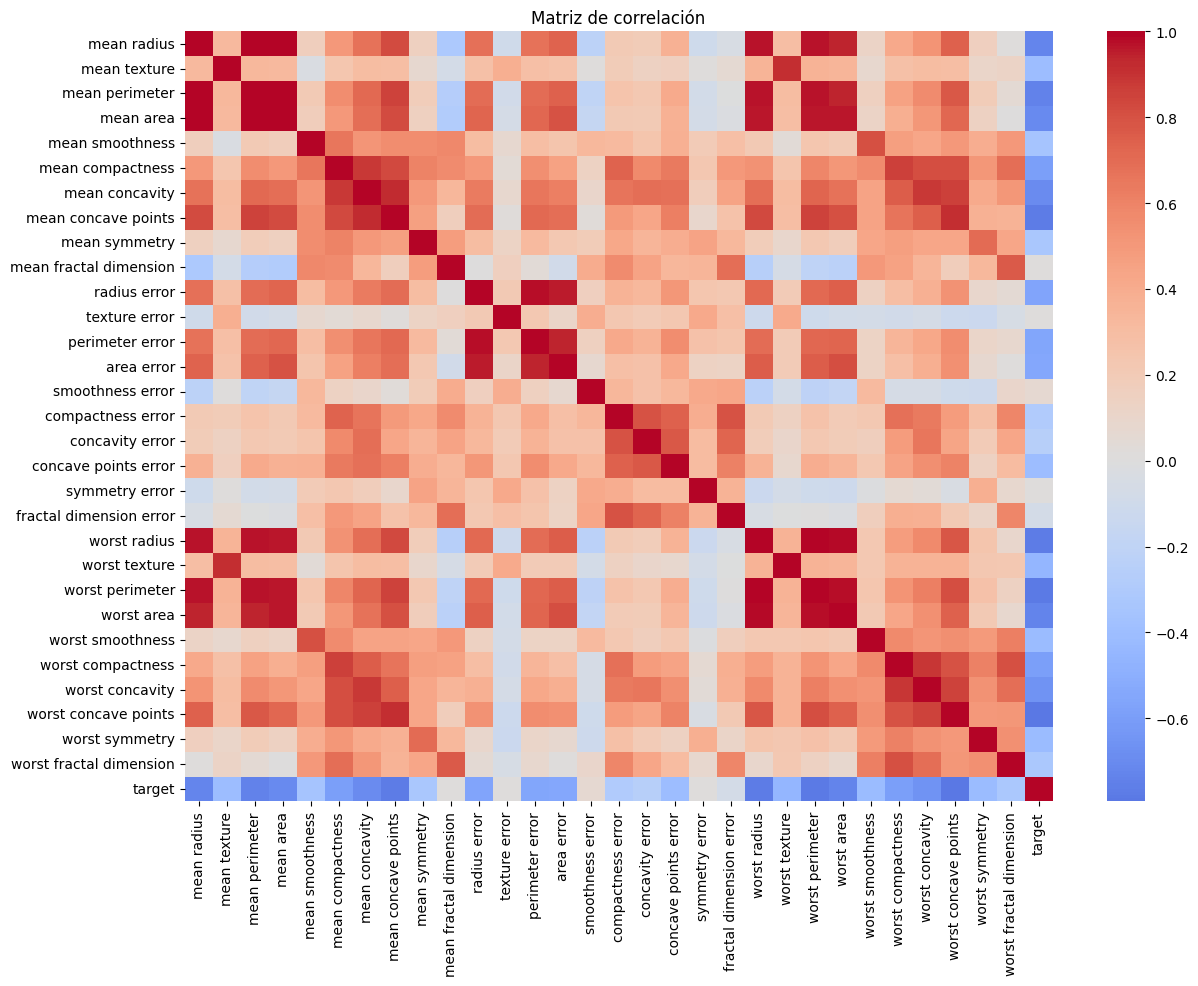

In [7]:
# ============================================================
# 7. MATRIZ DE CORRELACIÓN
# ============================================================

# Calculamos la correlación entre todas las variables numéricas
# La correlación mide qué tan relacionadas están dos variables
corr = df.corr()

# Crear figura
plt.figure(figsize=(14,10))

# Heatmap de correlaciones
#
# cmap="coolwarm":
#   colores cálidos -> correlación positiva
#   colores fríos   -> correlación negativa
#
# center=0:
#   centra la escala de colores en cero
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

# Título
plt.title("Matriz de correlación")

# Mostrar gráfico
plt.show()

## Interpretación de la matriz de correlación

Se observa la existencia de múltiples variables altamente correlacionadas, especialmente entre características geométricas relacionadas con el tamaño del tumor, como `radius`, `perimeter` y `area`.

Esto es esperable debido a que dichas variables describen propiedades similares de los tumores.

Además, la variable objetivo (`target`) presenta correlaciones importantes con varias características, lo cual indica que el dataset contiene información relevante para la tarea de clasificación.

La presencia de variables altamente correlacionadas puede introducir redundancia y multicolinealidad en algunos modelos de Machine Learning. Por esta razón, posteriormente se implementará una técnica de selección de características.

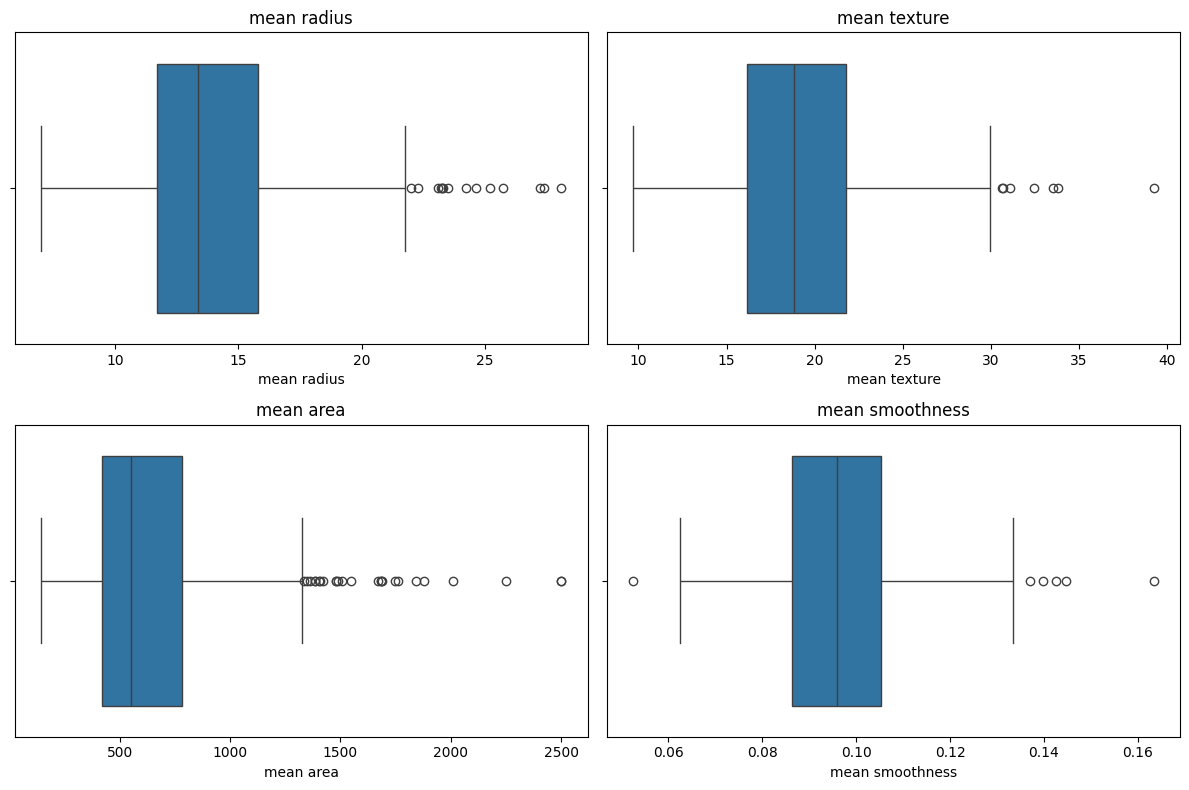

In [8]:
# ============================================================
# BOXPLOTS INDIVIDUALES
# ============================================================

# Crear figura con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Aplanar matriz de ejes para iterar fácilmente
axes = axes.flatten()

# Recorrer variables seleccionadas
for i, feature in enumerate(features):

    # Crear boxplot individual
    sns.boxplot(
        x=df[feature],
        ax=axes[i]
    )

    # Título de cada gráfico
    axes[i].set_title(feature)

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficos
plt.show()

## Interpretación de los boxplots individuales

Los boxplots individuales permiten visualizar de mejor manera la dispersión y los posibles valores atípicos de cada variable.

Se observa que variables como `mean radius` y especialmente `mean area` presentan varios outliers hacia valores altos, así como una distribución con cierta asimetría positiva.

Por otro lado, variables como `mean smoothness` muestran una dispersión menor y una distribución más concentrada.

Además, las diferencias de escala entre variables continúan siendo evidentes, lo cual refuerza la necesidad de aplicar estandarización antes del entrenamiento de modelos de Machine Learning.

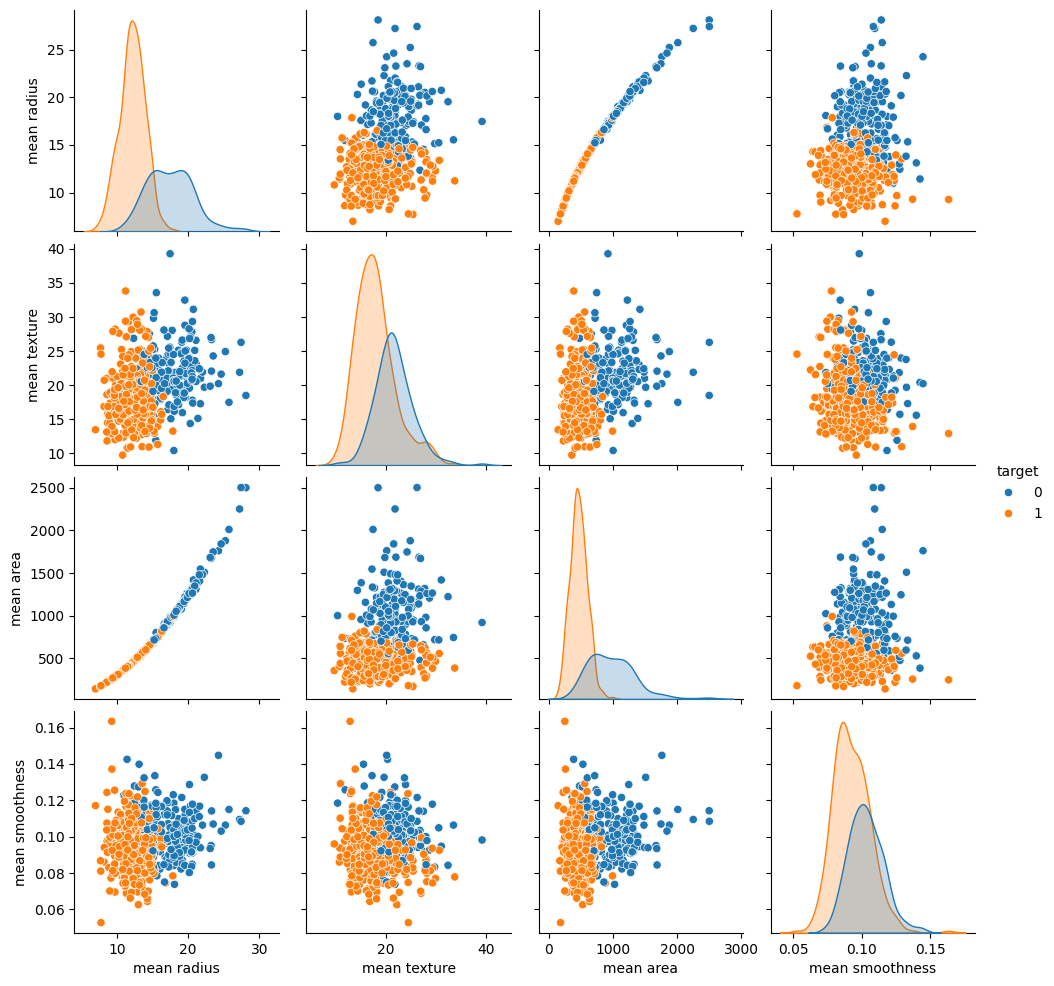

In [9]:
# ============================================================
# 9. RELACIÓN ENTRE VARIABLES Y CLASES
# ============================================================

# Seleccionamos algunas variables representativas
# junto con la variable objetivo (target)
#
# Estas variables fueron escogidas porque:
# - representan distintas propiedades del tumor
# - muestran diferencias de escala
# - presentan correlaciones importantes
selected_features = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean smoothness",
    "target"
]

# pairplot genera gráficos de dispersión entre pares de variables
# y distribuciones individuales en la diagonal
#
# hue="target":
# colorea los puntos según la clase:
# 0 -> maligno
# 1 -> benigno
#
# Esto permite visualizar:
# - separación entre clases
# - relaciones entre variables
# - posibles patrones de clasificación
sns.pairplot(
    df[selected_features],
    hue="target"
)

# Mostrar gráficos
plt.show()

## Relación entre variables y clases

El pairplot permite visualizar la relación entre distintas variables del dataset y cómo se distribuyen según la clase objetivo.

Se observa que variables como `mean radius` y `mean area` presentan una separación parcial entre tumores benignos y malignos, lo cual indica que contienen información relevante para la clasificación.

Además, algunas variables muestran relaciones altamente correlacionadas, especialmente entre características geométricas relacionadas con el tamaño del tumor.

También se aprecia cierto solapamiento entre clases, lo cual sugiere que el problema no es trivial, pero sí posee patrones que pueden ser aprendidos por modelos supervisados.

# Feature Extraction

La etapa de Feature Extraction aplica principalmente cuando se trabaja con datos no estructurados, como texto, imágenes, audio o series de tiempo.

En este proyecto se utiliza el Breast Cancer Wisconsin Dataset, el cual es un dataset tabular estructurado. Las variables predictoras ya corresponden a características numéricas extraídas previamente de imágenes médicas, tales como radio, textura, perímetro, área, suavidad, concavidad y simetría.

Por esta razón, no se requiere aplicar una etapa adicional de extracción de características como TF-IDF, embeddings, PCA sobre imágenes, MFCCs o lags temporales.

En lugar de Feature Extraction, el proyecto continuará con Feature Selection, donde se seleccionarán las variables más relevantes para el problema de clasificación.

# Feature Selection

En esta sección se implementará una técnica de selección de características tipo filter.  
El objetivo es identificar las variables más relevantes para clasificar tumores benignos y malignos.

Se utilizará `SelectKBest` con `f_classif`, que evalúa la relación estadística entre cada variable predictora y la variable objetivo.

In [10]:
# ============================================================
# 1. SEPARAR VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# ============================================================

# X contiene las variables predictoras del modelo.
# En este caso son todas las columnas excepto "target".
X = df.drop(columns=["target"])

# y contiene la variable objetivo.
# target indica la clase del tumor:
# 0 = maligno
# 1 = benigno
y = df["target"]

# Verificamos las dimensiones de X y y
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)


In [11]:
# ============================================================
# 2. FEATURE SELECTION CON SelectKBest
# ============================================================

# Importamos SelectKBest
# y el criterio estadístico f_classif
from sklearn.feature_selection import SelectKBest, f_classif

# Creamos el selector de variables
#
# score_func=f_classif:
# usa ANOVA F-test para evaluar qué tan
# relacionadas están las variables con la clase objetivo
#
# k=10:
# seleccionará las 10 variables más importantes
selector = SelectKBest(
    score_func=f_classif,
    k=10
)

# Ajustamos el selector usando X e y
selector.fit(X, y)

# Obtenemos los scores de cada variable
scores = selector.scores_

# Creamos un DataFrame para visualizar resultados
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores
})

# Ordenamos de mayor a menor importancia
feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

# Mostrar resultados
feature_scores.head(10)

,Feature,Score
27,worst concave points,964.385393
22,worst perimeter,897.944219
7,mean concave points,861.676020
20,worst radius,860.781707
2,mean perimeter,697.235272
23,worst area,661.600206
0,mean radius,646.981021
3,mean area,573.060747
6,mean concavity,533.793126
26,worst concavity,436.691939


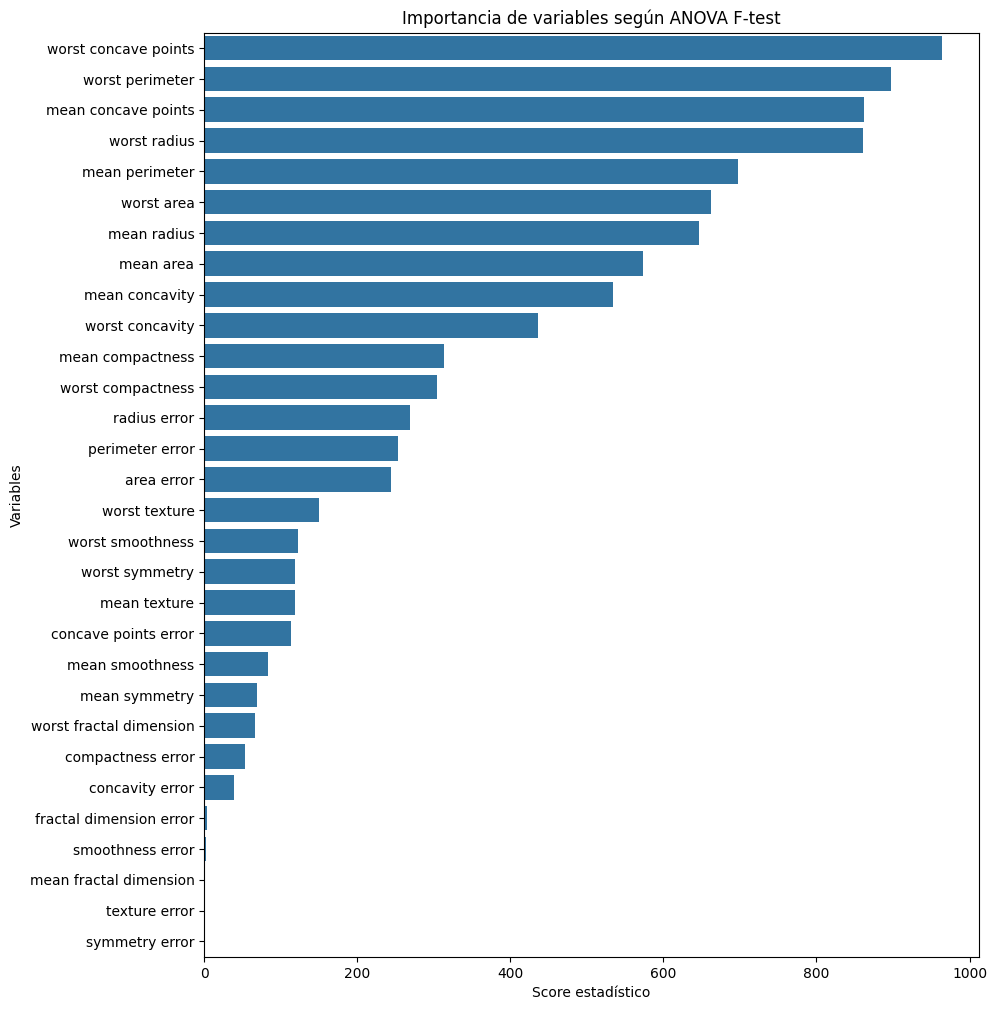

In [12]:
# ============================================================
# 3. IMPORTANCIA DE TODAS LAS VARIABLES
# ============================================================

# Ordenamos variables de mayor a menor score
feature_scores_sorted = feature_scores.sort_values(
    by="Score",
    ascending=False
)

# Crear figura
plt.figure(figsize=(10,12))

# Gráfico de barras horizontal
sns.barplot(
    data=feature_scores_sorted,
    x="Score",
    y="Feature"
)

# Título
plt.title("Importancia de variables según ANOVA F-test")

# Etiqueta eje X
plt.xlabel("Score estadístico")

# Etiqueta eje Y
plt.ylabel("Variables")

# Mostrar gráfico
plt.show()

## Consideración sobre Data Leakage

El análisis de importancia de variables realizado con `SelectKBest` en esta sección tiene únicamente un propósito exploratorio y visual dentro del EDA.

Es importante mencionar que ajustar el selector utilizando todo el dataset antes del entrenamiento podría generar *data leakage*, ya que se estaría utilizando información de todas las observaciones para seleccionar variables.

Por esta razón, durante el entrenamiento real de los modelos, la selección de características no se realizará de forma independiente sobre todo el dataset. En su lugar, `SelectKBest` será incluido dentro de un `Pipeline` de scikit-learn junto con el proceso de normalización y el modelo de clasificación.

De esta manera, la selección de variables será ajustada únicamente utilizando los datos de entrenamiento en cada fold de validación cruzada, evitando filtración de información (*data leakage*).

## Interpretación de la importancia de variables

El gráfico muestra la relevancia estadística de cada variable utilizando ANOVA F-test mediante `SelectKBest`.

Se observa que las variables con mayor score están principalmente relacionadas con características geométricas y de concavidad del tumor, como:

- `worst concave points`
- `worst perimeter`
- `mean concave points`
- `worst radius`
- `mean perimeter`

Estas variables presentan una mayor capacidad para diferenciar tumores benignos y malignos.

Por otro lado, algunas variables poseen scores considerablemente menores, lo cual sugiere que aportan menos información discriminativa para la tarea de clasificación.

Además, se observa que múltiples variables relacionadas con tamaño y geometría presentan scores altos, lo cual es consistente con las correlaciones observadas previamente durante el EDA.

Finalmente, este análisis se utiliza únicamente como exploración inicial. La selección definitiva de variables será realizada dentro de un `Pipeline` para evitar problemas de *data leakage* durante el entrenamiento y validación de los modelos.

In [ ]:
# Asistencia de ChatGPT utilizada para:
# explicación conceptual y estructuración del pipeline.

In [13]:
# ============================================================
# TRAIN / TEST SPLIT + PIPELINE + HYPERPARAMETER TUNING
# ============================================================

# ============================================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RepeatedStratifiedKFold,
    learning_curve
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.linear_model import LogisticRegression


# ============================================================
# 2. SEPARAR VARIABLES PREDICTORAS Y VARIABLE OBJETIVO
# ============================================================

# X contiene las variables predictoras
X = df.drop(columns=["target"])

# y contiene la variable objetivo
# 0 -> maligno
# 1 -> benigno
y = df["target"]


# ============================================================
# 3. DIVISIÓN TRAIN / TEST
# ============================================================

# Separamos los datos en:
#
# TRAIN -> usado para entrenamiento y tuning
# TEST  -> usado únicamente para evaluación final
#
# test_size=0.2:
# 20% de los datos serán reservados para test
#
# stratify=y:
# mantiene la proporción de clases
#
# random_state=42:
# garantiza reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Mostrar dimensiones
print("Dimensiones X_train:", X_train.shape)
print("Dimensiones X_test :", X_test.shape)

print("Dimensiones y_train:", y_train.shape)
print("Dimensiones y_test :", y_test.shape)


# ============================================================
# 4. CREAR PIPELINE
# ============================================================

# El pipeline evita data leakage porque:
#
# - StandardScaler se ajusta SOLO sobre train
# - SelectKBest se ajusta SOLO sobre train
#
# Todo ocurre correctamente dentro de cada fold
# de validación cruzada.

pipe_logreg = Pipeline([

    # --------------------------------------------------------
    # NORMALIZACIÓN
    # --------------------------------------------------------
    #
    # StandardScaler transforma las variables para que:
    #
    # media = 0
    # desviación estándar = 1
    #
    # Esto es importante porque:
    # Logistic Regression y SVM son sensibles a la escala
    ("scaler", StandardScaler()),


    # --------------------------------------------------------
    # FEATURE SELECTION
    # --------------------------------------------------------
    #
    # SelectKBest selecciona las variables más relevantes
    #
    # f_classif:
    # usa ANOVA F-test para medir relación estadística
    # entre variables y target
    ("feature_selection", SelectKBest(
        score_func=f_classif
    )),


    # --------------------------------------------------------
    # MODELO
    # --------------------------------------------------------
    #
    # Logistic Regression Regularizada
    #
    # penalty="l2":
    # regularización Ridge
    #
    # C:
    # inverso de lambda
    #
    # solver="liblinear":
    # adecuado para datasets pequeños y medianos
    ("classifier", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])


# ============================================================
# 5. VALIDACIÓN CRUZADA REPETIDA
# ============================================================

# RepeatedStratifiedKFold:
#
# - divide el dataset múltiples veces
# - mantiene proporción de clases
#
# n_splits=5:
# 5 folds
#
# n_repeats=2:
# repetir el proceso 2 veces
#
# Esto permite una evaluación más robusta.

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)


# ============================================================
# 6. DEFINIR HIPERPARÁMETROS
# ============================================================

# feature_selection__k:
# número de variables seleccionadas
#
# classifier__C:
# hiperparámetro de regularización
#
# C pequeño -> mayor regularización
# C grande  -> menor regularización

param_grid = {

    "feature_selection__k": [5, 10, 15, 20, 25, 30],

    "classifier__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}


# ============================================================
# 7. GRID SEARCH
# ============================================================

# GridSearchCV prueba TODAS las combinaciones
# posibles de hiperparámetros.
#
# scoring="f1":
# usamos F1 porque balancea:
#
# - precision
# - recall
#
# cv=cv:
# usa repeated cross validation

grid_logreg = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)


# ============================================================
# 8. ENTRENAR GRID SEARCH
# ============================================================

# IMPORTANTE:
#
# El tuning ocurre SOLO sobre TRAIN.
#
# El conjunto TEST permanece completamente
# independiente para evaluación final.

grid_logreg.fit(X_train, y_train)


# ============================================================
# 9. MOSTRAR MEJORES HIPERPARÁMETROS
# ============================================================

print("======================================")
print("MEJORES HIPERPARÁMETROS")
print("======================================")

print(grid_logreg.best_params_)

print("\n======================================")
print("MEJOR F1 EN VALIDACIÓN CRUZADA")
print("======================================")

print(grid_logreg.best_score_)


# ============================================================
# 10. RESULTADOS COMPLETOS
# ============================================================

# Convertimos resultados a DataFrame
results = pd.DataFrame(
    grid_logreg.cv_results_
)

# Mostrar primeras filas
results.head()

Dimensiones X_train: (455, 30)
Dimensiones X_test : (114, 30)
Dimensiones y_train: (455,)
Dimensiones y_test : (114,)
MEJORES HIPERPARÁMETROS
{'classifier__C': 0.1, 'feature_selection__k': 25}

MEJOR F1 EN VALIDACIÓN CRUZADA
0.9860711749388464


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_feature_selection__k,params,split0_test_score,split1_test_score,split2_test_score,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,0.013953,0.006610,0.010012,0.005642,0.001,5,"{'classifier__C': 0.001, 'feature_selection__k...",0.956522,0.964286,0.928571,...,0.962801,0.953642,0.951542,0.969298,0.956140,0.949227,0.960526,0.951754,0.956493,0.005782
1,0.021386,0.006460,0.013792,0.004755,0.001,10,"{'classifier__C': 0.001, 'feature_selection__k...",0.956522,0.945455,0.938053,...,0.958242,0.942222,0.951327,0.960177,0.953846,0.940397,0.958242,0.951542,0.952369,0.006202
2,0.012763,0.004608,0.008425,0.003647,0.001,15,"{'classifier__C': 0.001, 'feature_selection__k...",0.929825,0.936937,0.921739,...,0.956140,0.940397,0.945055,0.953846,0.947368,0.945055,0.947598,0.949672,0.949136,0.004889
3,0.018031,0.004775,0.012922,0.003990,0.001,20,"{'classifier__C': 0.001, 'feature_selection__k...",0.955752,0.955752,0.940171,...,0.962801,0.964758,0.964758,0.973568,0.958606,0.962637,0.967033,0.956332,0.964071,0.005248
4,0.016411,0.005787,0.012130,0.004205,0.001,25,"{'classifier__C': 0.001, 'feature_selection__k...",0.939130,0.946429,0.940171,...,0.960526,0.951965,0.958425,0.965066,0.960699,0.954048,0.956332,0.954048,0.957606,0.003924


## Interpretación de la optimización de hiperparámetros

Se separó el dataset en un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento contiene 455 observaciones y el conjunto de prueba contiene 114 observaciones.

La optimización de hiperparámetros se realizó únicamente sobre el conjunto de entrenamiento utilizando `GridSearchCV` con `RepeatedStratifiedKFold`. Esto evita que el conjunto de prueba influya en la selección del modelo.

Los mejores hiperparámetros encontrados fueron:

- `C = 0.1`
- `k = 25`

El valor `C = 0.1` indica que el mejor modelo utiliza una regularización moderada. Además, `k = 25` indica que el modelo obtuvo mejor desempeño usando 25 de las 30 variables disponibles.

El mejor F1 promedio en validación cruzada fue aproximadamente 0.986, lo cual sugiere que el modelo tiene un desempeño alto y estable durante la validación.

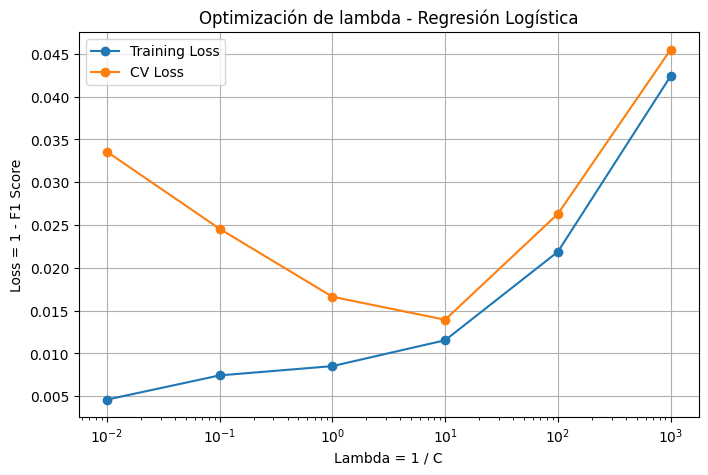

In [14]:
# ============================================================
# 11. GRÁFICA DE OPTIMIZACIÓN DE LAMBDA
# Training Loss vs CV Loss
# ============================================================

# Convertimos los resultados del GridSearchCV a DataFrame
results = pd.DataFrame(grid_logreg.cv_results_)

# Extraemos C y k
results["C"] = results["param_classifier__C"].astype(float)
results["k"] = results["param_feature_selection__k"].astype(int)

# Lambda = 1 / C
results["lambda"] = 1 / results["C"]

# Usamos el mejor k encontrado
best_k = grid_logreg.best_params_["feature_selection__k"]

# Filtramos solo resultados con el mejor k
results_best_k = results[results["k"] == best_k].copy()

# Ordenamos por lambda
results_best_k = results_best_k.sort_values("lambda")

# Como GridSearchCV devuelve F1 Score, convertimos a pérdida:
# Loss = 1 - F1
results_best_k["train_loss"] = 1 - results_best_k["mean_train_score"]
results_best_k["cv_loss"] = 1 - results_best_k["mean_test_score"]

# Graficamos Training Loss y CV Loss
plt.figure(figsize=(8,5))

plt.plot(
    results_best_k["lambda"],
    results_best_k["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    results_best_k["lambda"],
    results_best_k["cv_loss"],
    marker="o",
    label="CV Loss"
)

plt.xscale("log")

plt.title("Optimización de lambda - Regresión Logística")
plt.xlabel("Lambda = 1 / C")
plt.ylabel("Loss = 1 - F1 Score")
plt.grid(True)
plt.legend()
plt.show()

## Interpretación de la optimización de lambda

La gráfica muestra el comportamiento del modelo frente a diferentes niveles de regularización (`lambda`).

Se presentan dos curvas:

- **Training Loss**: error sobre el conjunto de entrenamiento.
- **CV Loss**: error promedio obtenido mediante validación cruzada.

Recordar que:

\[
\lambda = \frac{1}{C}
\]

Por lo tanto:

- valores pequeños de `lambda` implican poca regularización,
- valores grandes de `lambda` implican mayor regularización.

---

### Análisis de la gráfica

Cuando `lambda` es muy pequeño (lado izquierdo de la gráfica), el modelo tiene poca regularización. En esta zona el modelo puede ajustarse demasiado a los datos de entrenamiento, produciendo overfitting. Esto se observa porque el `Training Loss` es muy bajo.

A medida que aumenta `lambda`, el `CV Loss` disminuye hasta alcanzar un mínimo cercano a:

\[
\lambda \approx 10
\]

Este punto representa el mejor balance entre bias y variance, ya que el modelo logra generalizar mejor sobre datos no vistos.

Sin embargo, cuando `lambda` continúa aumentando, tanto el `Training Loss` como el `CV Loss` empiezan a crecer. Esto indica que el modelo se vuelve demasiado simple debido a una regularización excesiva, generando underfitting.

En conclusión, la gráfica evidencia que un nivel intermedio de regularización produce el mejor desempeño del modelo.

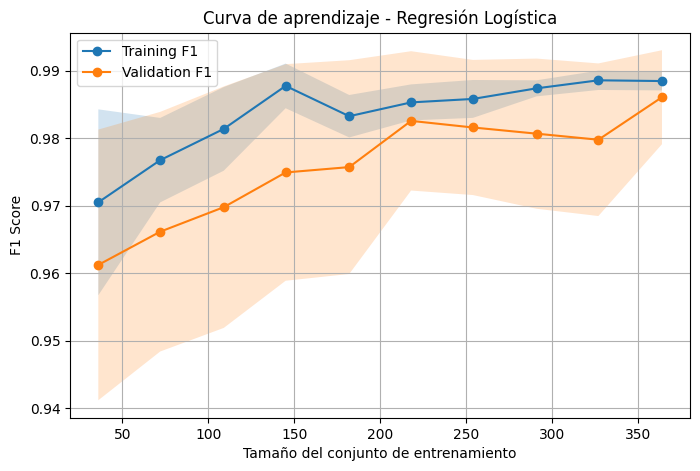

In [15]:
# ============================================================
# 12. CURVA DE APRENDIZAJE
# ============================================================

# Tomamos el mejor modelo encontrado
best_logreg_model = grid_logreg.best_estimator_

# Calculamos la curva de aprendizaje usando solo TRAIN
# para no contaminar el conjunto TEST.
train_sizes, train_scores, cv_scores = learning_curve(
    estimator=best_logreg_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculamos promedios
train_mean = np.mean(train_scores, axis=1)
cv_mean = np.mean(cv_scores, axis=1)

# Calculamos desviaciones estándar
train_std = np.std(train_scores, axis=1)
cv_std = np.std(cv_scores, axis=1)

# Graficamos la curva
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training F1"
)

plt.plot(
    train_sizes,
    cv_mean,
    marker="o",
    label="Validation F1"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    cv_mean - cv_std,
    cv_mean + cv_std,
    alpha=0.2
)

plt.title("Curva de aprendizaje - Regresión Logística")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1 Score")
plt.grid(True)
plt.legend()
plt.show()

## Interpretación de la curva de aprendizaje

La curva de aprendizaje muestra cómo cambia el desempeño del modelo a medida que aumenta el tamaño del conjunto de entrenamiento.

Se presentan dos curvas:

- **Training F1**: desempeño del modelo sobre los datos de entrenamiento.
- **Validation F1**: desempeño promedio obtenido mediante validación cruzada.

---

### Análisis de la gráfica

A medida que aumenta la cantidad de datos de entrenamiento, el desempeño tanto de entrenamiento como de validación mejora progresivamente.

Se observa que ambas curvas permanecen relativamente cercanas durante todo el proceso. Esto indica que el modelo presenta buena capacidad de generalización y no evidencia un sobreajuste significativo.

Además, los valores de F1 Score son altos en ambas curvas, alcanzando valores cercanos a 0.98 y 0.99. Esto sugiere que el modelo logra un desempeño consistente tanto en entrenamiento como en validación.

El pequeño gap entre las curvas indica baja varianza y un balance adecuado entre bias y variance.

Las bandas sombreadas representan la desviación estándar obtenida entre los distintos folds de validación cruzada. La baja amplitud de estas bandas indica estabilidad en el desempeño del modelo.

En conclusión, la curva de aprendizaje evidencia que el modelo de Regresión Logística generaliza adecuadamente y se beneficia del aumento de datos de entrenamiento.

In [15]:
# Asistencia de ChatGPT utilizada para:
# explicación conceptual y estructuración del pipeline.

In [16]:
# ============================================================
# COMPARACIÓN ESTADÍSTICA JUSTA ENTRE DOS MODELOS LINEALES
# Logistic Regression vs Linear SVM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

from scipy.stats import wilcoxon


# ============================================================
# 1. VALIDACIÓN CRUZADA REPETIDA
# ============================================================

cv_compare = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)


# ============================================================
# 2. MODELO BASE: REGRESIÓN LOGÍSTICA REGULARIZADA
# ============================================================

logreg_model = Pipeline([

    # Normalización
    ("scaler", StandardScaler()),

    # Selección de variables tipo filter
    ("feature_selection", SelectKBest(
        score_func=f_classif,
        k=25
    )),

    # Modelo lineal regularizado
    ("classifier", LogisticRegression(
        penalty="l2",
        C=0.1,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])


# ============================================================
# 3. MODELO COMPARATIVO: LINEAR SVM
# ============================================================

linear_svm_model = Pipeline([

    # Normalización
    ("scaler", StandardScaler()),

    # Misma selección de variables para comparación justa
    ("feature_selection", SelectKBest(
        score_func=f_classif,
        k=25
    )),

    # SVM lineal regularizado
    ("classifier", LinearSVC(
        C=0.1,
        max_iter=10000,
        random_state=42
    ))
])


# ============================================================
# 4. OBTENER SCORES CON LOS MISMOS FOLDS
# ============================================================

logreg_scores = cross_val_score(
    logreg_model,
    X_train,
    y_train,
    cv=cv_compare,
    scoring="f1",
    n_jobs=-1
)

linear_svm_scores = cross_val_score(
    linear_svm_model,
    X_train,
    y_train,
    cv=cv_compare,
    scoring="f1",
    n_jobs=-1
)


# ============================================================
# 5. RESUMEN DE RESULTADOS
# ============================================================

print("======================================")
print("REGRESIÓN LOGÍSTICA")
print("======================================")
print("Scores F1:", logreg_scores)
print("Media F1:", np.mean(logreg_scores))
print("Desviación estándar:", np.std(logreg_scores))

print("\n======================================")
print("LINEAR SVM")
print("======================================")
print("Scores F1:", linear_svm_scores)
print("Media F1:", np.mean(linear_svm_scores))
print("Desviación estándar:", np.std(linear_svm_scores))


# ============================================================
# 6. TABLA COMPARATIVA
# ============================================================

comparison_df = pd.DataFrame({
    "Fold": np.arange(1, len(logreg_scores) + 1),
    "Logistic Regression F1": logreg_scores,
    "Linear SVM F1": linear_svm_scores,
    "Difference": linear_svm_scores - logreg_scores
})

comparison_df

REGRESIÓN LOGÍSTICA
Scores F1: [0.98275862 0.98245614 0.99130435 0.99130435 0.98245614 0.98245614
 0.97391304 1.         0.99130435 0.98275862]
Media F1: 0.9860711749388464
Desviación estándar: 0.0069652141397423106

LINEAR SVM
Scores F1: [0.97435897 0.99115044 0.98245614 0.99130435 0.97345133 0.99115044
 0.97391304 0.96491228 0.99130435 0.96610169]
Media F1: 0.9800103041846675
Desviación estándar: 0.010211916266427559


,Fold,Logistic Regression F1,Linear SVM F1,Difference
0,1,0.982759,0.974359,-0.008400
1,2,0.982456,0.991150,0.008694
2,3,0.991304,0.982456,-0.008848
3,4,0.991304,0.991304,0.000000
4,5,0.982456,0.973451,-0.009005
5,6,0.982456,0.991150,0.008694
6,7,0.973913,0.973913,0.000000
7,8,1.000000,0.964912,-0.035088
8,9,0.991304,0.991304,0.000000
9,10,0.982759,0.966102,-0.016657


## Interpretación de la comparación entre modelos

Se realizó una comparación estadística entre dos modelos lineales:

- Regresión Logística Regularizada
- Linear Support Vector Machine (Linear SVM)

La comparación se realizó utilizando `RepeatedStratifiedKFold` con:

- 5 folds
- 2 repeticiones

Esto permitió obtener múltiples valores de F1 Score para cada modelo y realizar posteriormente un test estadístico.

---

### Resultados obtenidos

#### Regresión Logística

- F1 promedio: 0.9861
- Desviación estándar: 0.0070

#### Linear SVM

- F1 promedio: 0.9800
- Desviación estándar: 0.0102

---

### Análisis de resultados

La Regresión Logística obtuvo un F1 promedio ligeramente superior al de Linear SVM.

Además, la desviación estándar de Logistic Regression es menor, lo cual indica un desempeño más estable entre folds.

En la tabla comparativa se observa que en varios folds ambos modelos obtienen resultados muy similares. Sin embargo, Logistic Regression supera a Linear SVM en la mayoría de iteraciones.

La diferencia negativa en la columna `Difference` indica folds donde Logistic Regression obtuvo mejor desempeño que Linear SVM.

---

### Interpretación metodológica

La comparación se realizó entre dos modelos lineales para garantizar una comparación más justa.

Ambos modelos:

- utilizan regularización,
- trabajan sobre el mismo conjunto de variables,
- usan el mismo preprocesamiento,
- y fueron evaluados con exactamente los mismos folds de validación cruzada.

Esto permite que las diferencias observadas provengan principalmente del comportamiento del algoritmo y no de diferencias estructurales entre modelos lineales y no lineales.

En general, ambos modelos muestran un desempeño alto y consistente sobre el dataset Breast Cancer Wisconsin.

In [17]:
# ============================================================
# 8. TEST DE HIPÓTESIS: WILCOXON SIGNED-RANK TEST
# ============================================================

# Hipótesis:
#
# H0:
# No existe diferencia estadísticamente significativa
# entre Logistic Regression y Linear SVM.
#
# H1:
# Sí existe diferencia estadísticamente significativa
# entre ambos modelos.
#
# alpha = 0.05

statistic, p_value = wilcoxon(
    logreg_scores,
    linear_svm_scores
)

alpha = 0.05

print("======================================")
print("TEST DE WILCOXON")
print("======================================")

print("Estadístico:", statistic)
print("p-value:", p_value)

if p_value < alpha:

    print("\nConclusión:")
    print("Se rechaza H0.")
    print("Existe diferencia estadísticamente significativa entre los modelos.")

else:

    print("\nConclusión:")
    print("No se rechaza H0.")
    print("No existe evidencia suficiente de diferencia estadísticamente significativa.")

TEST DE WILCOXON
Estadístico: 5.0
p-value: 0.15625

Conclusión:
No se rechaza H0.
No existe evidencia suficiente de diferencia estadísticamente significativa.


## Test de hipótesis: Wilcoxon Signed-Rank Test

Después de obtener los F1 Scores de ambos modelos en los mismos folds de validación cruzada, se aplicó el test no paramétrico de Wilcoxon Signed-Rank.

Este test permite comparar estadísticamente el desempeño de dos modelos utilizando muestras pareadas, sin asumir normalidad en los datos.

---

### Hipótesis planteadas

#### Hipótesis nula (H0)

No existe diferencia estadísticamente significativa entre el desempeño de Regresión Logística y Linear SVM.

#### Hipótesis alternativa (H1)

Sí existe diferencia estadísticamente significativa entre ambos modelos.

---

### Resultados obtenidos

- Estadístico de Wilcoxon: 5.0
- p-value: 0.15625
- Nivel de significancia: \(\alpha = 0.05\)

---

### Interpretación

El p-value obtenido es mayor que 0.05:

\[
0.15625 > 0.05
\]

Por lo tanto, no se rechaza la hipótesis nula.

Esto significa que no existe evidencia estadística suficiente para afirmar que uno de los modelos tiene un desempeño significativamente mejor que el otro.

Aunque Regresión Logística obtuvo un F1 promedio ligeramente superior, la diferencia observada podría deberse al azar asociado a las particiones de validación cruzada.

En conclusión, ambos modelos presentan desempeños estadísticamente similares sobre este dataset.

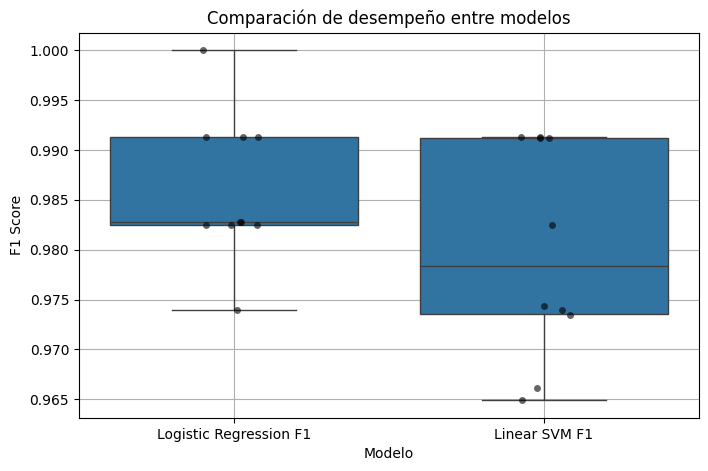

In [18]:
# ============================================================
# 9. VISUALIZACIÓN DE SCORES POR MODELO
# ============================================================

# Convertimos la tabla a formato largo
# para facilitar la visualización con seaborn

comparison_long = comparison_df.melt(
    id_vars="Fold",

    # Columnas que queremos comparar
    value_vars=[
        "Logistic Regression F1",
        "Linear SVM F1"
    ],

    # Nombre de la columna que contendrá el nombre del modelo
    var_name="Modelo",

    # Nombre de la columna que contendrá los scores
    value_name="F1 Score"
)

# Crear figura
plt.figure(figsize=(8,5))

# Boxplot
#
# Resume:
# - mediana
# - cuartiles
# - dispersión
sns.boxplot(
    data=comparison_long,
    x="Modelo",
    y="F1 Score"
)

# Stripplot
#
# Muestra cada score individual obtenido
# en cada fold de validación cruzada
sns.stripplot(
    data=comparison_long,
    x="Modelo",
    y="F1 Score",
    color="black",
    alpha=0.6
)

# Títulos
plt.title("Comparación de desempeño entre modelos")

plt.ylabel("F1 Score")
plt.xlabel("Modelo")

plt.grid(True)

plt.show()

## Interpretación de la visualización comparativa entre modelos

La gráfica muestra la distribución de los F1 Scores obtenidos por cada modelo durante la validación cruzada repetida.

Se utilizaron:

- Regresión Logística Regularizada
- Linear SVM

Cada punto negro representa el F1 Score obtenido en un fold específico de validación cruzada.

El boxplot resume estadísticamente la distribución de los resultados mediante:

- mediana,
- rango intercuartílico,
- dispersión de los scores.

---

### Análisis de resultados

Se observa que ambos modelos presentan desempeños altos y relativamente similares, con valores de F1 cercanos a 0.98 y 0.99.

La Regresión Logística presenta una distribución ligeramente más estable y concentrada, mientras que Linear SVM muestra una dispersión un poco mayor entre folds.

Además, la mediana de Logistic Regression es ligeramente superior a la de Linear SVM, lo cual coincide con los resultados promedio obtenidos anteriormente.

Sin embargo, las distribuciones de ambos modelos se superponen considerablemente, lo que sugiere que las diferencias de desempeño no son muy grandes.

Esto es consistente con el resultado del test de Wilcoxon, donde no se encontró evidencia estadísticamente significativa para afirmar que uno de los modelos sea superior al otro.

En conclusión, ambos modelos presentan un desempeño alto y comparable sobre el dataset Breast Cancer Wisconsin.

In [ ]:
# Asistencia de ChatGPT utilizada para:
# explicación conceptual y estructuración del pipeline.

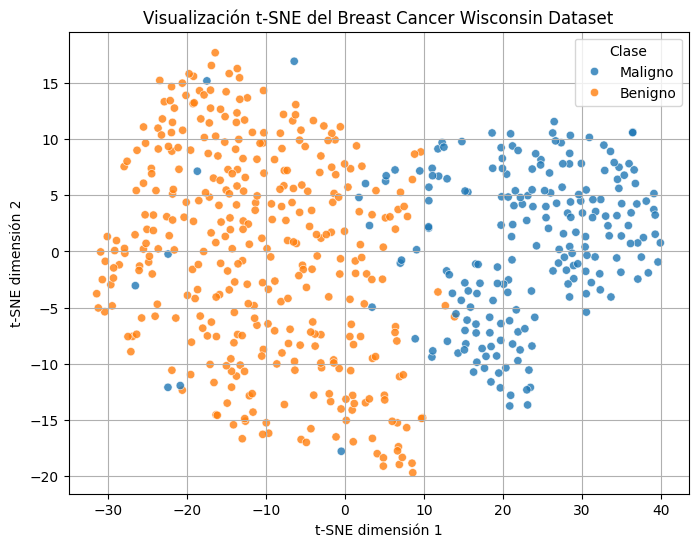

In [19]:
# ============================================================
# VISUALIZACIÓN DEL ESPACIO DE CARACTERÍSTICAS CON t-SNE
# ============================================================

# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE


# ============================================================
# 2. PREPARAR VARIABLES
# ============================================================

# X contiene las variables predictoras
X = df.drop(columns=["target"])

# y contiene la variable objetivo
# 0 = maligno
# 1 = benigno
y = df["target"]


# ============================================================
# 3. NORMALIZAR DATOS
# ============================================================

# t-SNE trabaja con distancias entre observaciones.
# Por eso es importante escalar las variables antes,
# ya que el dataset tiene variables en escalas muy distintas.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 4. APLICAR t-SNE
# ============================================================

# t-SNE reduce las 30 variables originales a 2 dimensiones.
#
# n_components=2:
# queremos visualizar en un plano 2D.
#
# perplexity:
# controla el número aproximado de vecinos considerados.
#
# random_state:
# permite reproducibilidad.
#
# init="pca":
# inicializa el algoritmo usando PCA, lo cual suele ser más estable.
#
# learning_rate="auto":
# sklearn elige automáticamente una tasa adecuada.

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)


# ============================================================
# 5. CREAR DATAFRAME PARA GRAFICAR
# ============================================================

tsne_df = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1],
    "target": y
})

# Convertimos la clase numérica a etiqueta textual
tsne_df["Clase"] = tsne_df["target"].map({
    0: "Maligno",
    1: "Benigno"
})


# ============================================================
# 6. GRAFICAR t-SNE
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x="TSNE_1",
    y="TSNE_2",
    hue="Clase",
    alpha=0.8
)

plt.title("Visualización t-SNE del Breast Cancer Wisconsin Dataset")
plt.xlabel("t-SNE dimensión 1")
plt.ylabel("t-SNE dimensión 2")
plt.grid(True)
plt.legend(title="Clase")

plt.show()

## Interpretación de la visualización t-SNE

La visualización t-SNE muestra una representación bidimensional del espacio original de características del dataset Breast Cancer Wisconsin.

Cada punto representa una observación del dataset y el color corresponde a la clase del tumor:

- Azul: Maligno
- Naranja: Benigno

---

### Análisis de resultados

Se observa que ambas clases forman agrupaciones relativamente diferenciadas en el espacio reducido por t-SNE.

La mayoría de observaciones benignas se concentran hacia el lado izquierdo de la gráfica, mientras que las observaciones malignas aparecen principalmente hacia el lado derecho.

Aunque existe cierto solapamiento entre algunas observaciones, la separación visual entre grupos es bastante clara.

Esto sugiere que las variables del dataset contienen información discriminativa suficiente para separar ambas clases.

---

### Relación con los modelos utilizados

La visualización t-SNE permitió observar que las clases presentan una estructura relativamente separable, lo cual justifica el uso de modelos lineales como:

- Regresión Logística Regularizada
- Linear SVM

Además, esta representación ayuda a entender por qué ambos modelos obtuvieron métricas altas de clasificación.

---

### Consideraciones metodológicas

La técnica t-SNE fue utilizada únicamente con fines exploratorios y de visualización.

No se utilizó como entrada del modelo ni como parte del pipeline predictivo, por lo que no afecta el proceso de entrenamiento ni introduce data leakage en la evaluación final.

# Conclusiones

1. El análisis exploratorio de datos permitió identificar que el dataset Breast Cancer Wisconsin presenta variables altamente correlacionadas y una separación relativamente clara entre las clases benigna y maligna.

2. La normalización de variables resultó importante debido a que las características originales presentan escalas muy diferentes. Esto fue especialmente relevante para modelos basados en distancias y regularización.

3. La técnica de selección de variables `SelectKBest` permitió identificar las características más relevantes del dataset, destacando variables relacionadas con concavidad, perímetro y radio del tumor.

4. La optimización de hiperparámetros mediante validación cruzada permitió encontrar configuraciones adecuadas para Regresión Logística Regularizada, obteniendo un desempeño estable y alto en términos de F1 Score.

5. La curva de aprendizaje mostró que el modelo generaliza adecuadamente y no presenta evidencia importante de overfitting, ya que las curvas de entrenamiento y validación permanecen cercanas.

6. La visualización mediante t-SNE permitió observar agrupaciones relativamente diferenciadas entre clases, lo cual ayudó a justificar el uso de modelos lineales para la clasificación.

7. En la comparación estadística entre Regresión Logística y Linear SVM, ambos modelos obtuvieron desempeños altos y similares. Aunque Regresión Logística alcanzó un F1 promedio ligeramente superior, el test de Wilcoxon indicó que no existe evidencia estadísticamente significativa para afirmar que uno de los modelos sea mejor que el otro.

8. Finalmente, el uso de pipelines permitió construir un flujo de trabajo modular, reproducible y libre de data leakage, integrando correctamente normalización, selección de variables y entrenamiento de modelos.

# Referencias

[1] C. Bishop, *Pattern Recognition and Machine Learning*. New York, NY, USA: Springer, 2006.

[2] T. Hastie, R. Tibshirani and J. Friedman, *The Elements of Statistical Learning*, 2nd ed. New York, NY, USA: Springer, 2009.

[3] F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[4] L. van der Maaten and G. Hinton, “Visualizing Data using t-SNE,” *Journal of Machine Learning Research*, vol. 9, pp. 2579–2605, 2008.

[5] F. Wilcoxon, “Individual Comparisons by Ranking Methods,” *Biometrics Bulletin*, vol. 1, no. 6, pp. 80–83, 1945.

[6] Scikit-learn Developers, “Scikit-learn documentation,” [Online]. Available: https://scikit-learn.org/stable/. [Accessed: 17-May-2026].

[7] OpenAI, “ChatGPT,” [Online]. Available: https://chat.openai.com/. [Accessed: 17-May-2026].